<a href="https://colab.research.google.com/github/pstrings/MachineLearningTraining/blob/main/Food_Delivery_Time_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# All the required Imports:

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, accuracy_score, auc, precision_score, recall_score, roc_curve

# Importing Data


In [323]:
delivery_data = pd.read_csv("/content/drive/MyDrive/Machine Learning Course/TuteDudeCourse/Food_Delivery_Time_Prediction.csv")
delivery_data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


# Adding Time Based Features

In [324]:
delivery_data["Rush_Hour"] = delivery_data["Order_Time"].isin(["Morning", "Evening"]).astype(int)

In [325]:
delivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

# Descriptive Statistics

In [326]:
delivery_data.describe()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Rush_Hour
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650,0.480000
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706,0.500854
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000,0.000000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500,0.000000
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000,0.000000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000,1.000000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000,1.000000


# Correlation Analysis

In [327]:
corr_matrix = delivery_data.corr(numeric_only=True)
corr_matrix["Delivery_Time"].sort_values(ascending=False)

,Delivery_Time
Delivery_Time,1.000000
Rush_Hour,0.005871
Order_Cost,-0.009307
Delivery_Person_Experience,-0.019098
Customer_Rating,-0.021952
Tip_Amount,-0.029154
Distance,-0.075143
Restaurant_Rating,-0.091855


- From this we can see that Delivery Time is highly negatively correlated with Restaurant Rating and Distance.

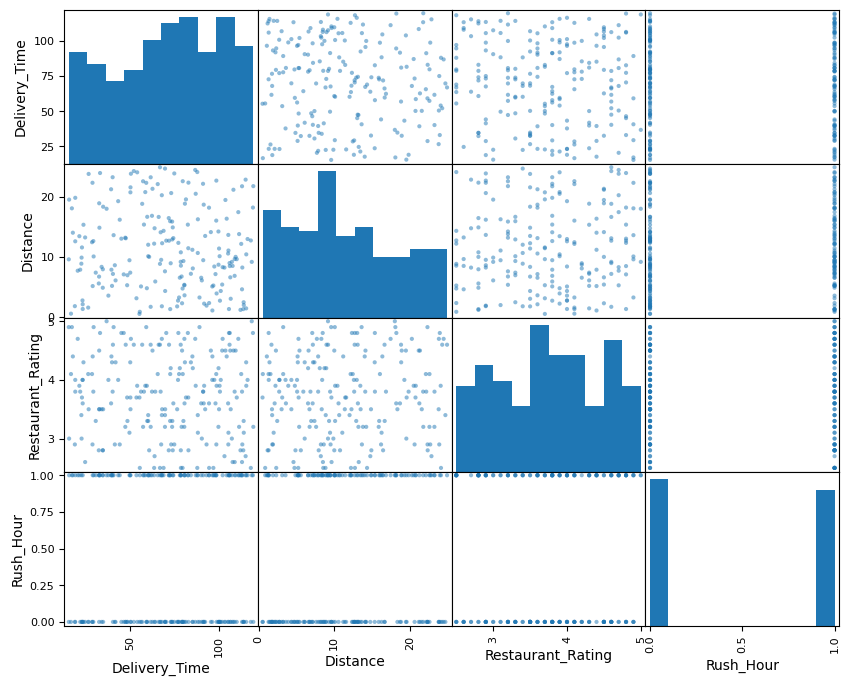

In [328]:
pd.plotting.scatter_matrix(delivery_data[['Delivery_Time', 'Distance', 'Restaurant_Rating', 'Rush_Hour']], figsize=(10, 8))
plt.show()

In [329]:
delivery_data.isna().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


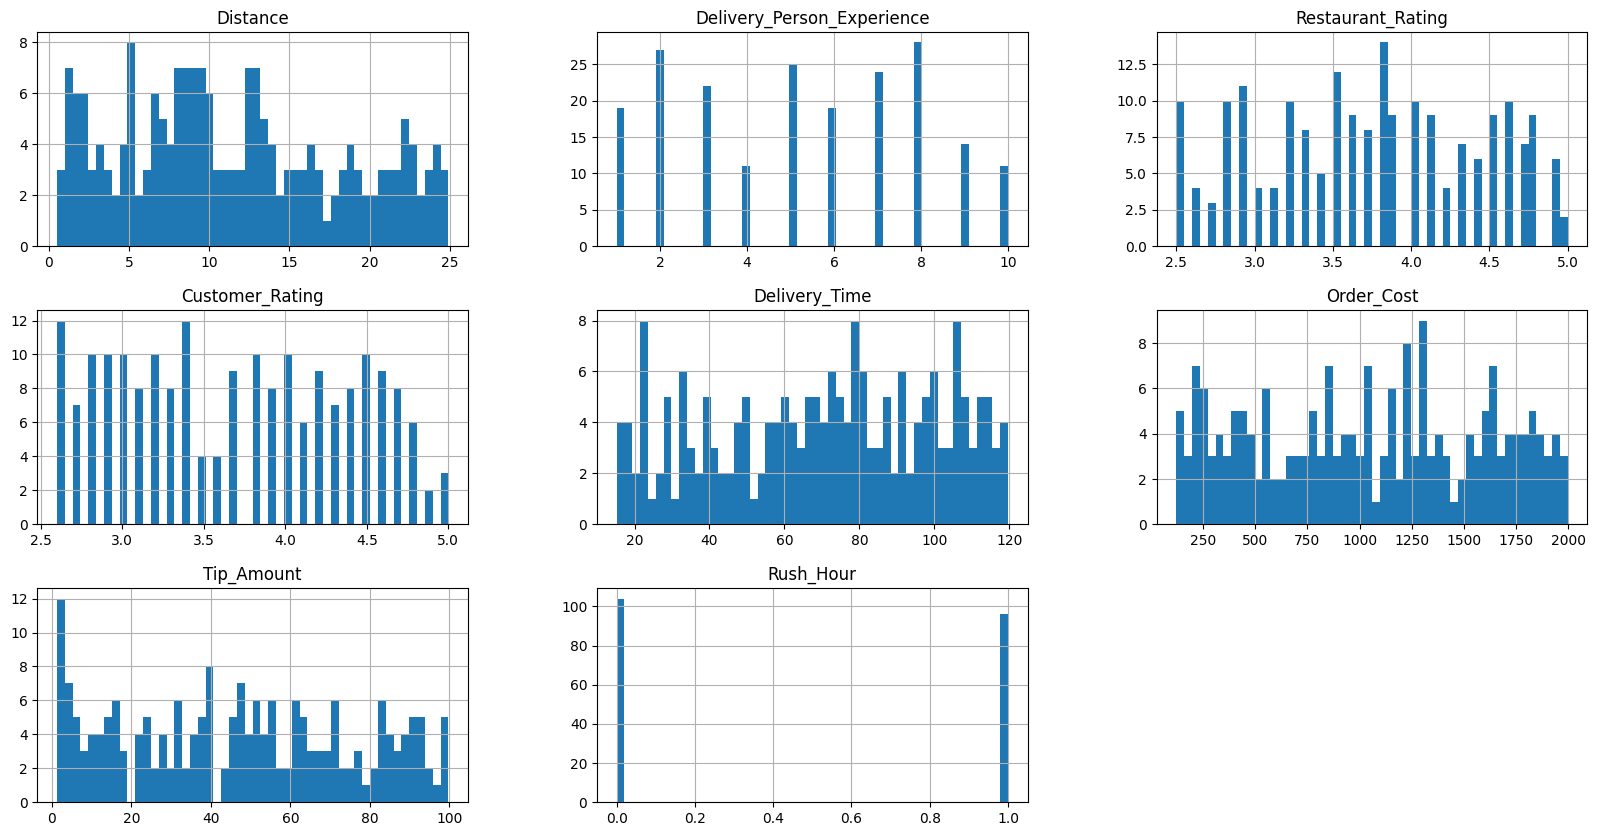

In [330]:
delivery_data.hist(bins=50, figsize=(20, 10))
plt.show()

# Split train and test data set

Splitting training and testing dataset to avoid data snooping bias.

-- Since this is mentioned in the requirement, I'll be using only these columns for Linear Regression.
( Use Linear Regression to predict the Delivery Time based on features like Distance, Traffic_Conditions, and Order_Priority)

But from my own judgement I'll add a few more columns in X that may affect delivery time namely: Weather_Conditions, Tip_Amount, and Order_Time

In [331]:
X = delivery_data[['Distance', 'Traffic_Conditions', 'Order_Priority', 'Weather_Conditions', 'Order_Time', 'Tip_Amount', 'Rush_Hour']]
y = delivery_data['Delivery_Time']

In [332]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Analysis on the training data

But before that I'll create a copy of the X train so that I can always revert to original after any manipulation.

In [333]:
X_train_copy = X_train.copy()

# Feature Scaling

In [334]:
numerical_data = ['Distance', 'Tip_Amount']
ordinal_categorical_data = ['Traffic_Conditions', 'Order_Priority']
categorical_data = ['Weather_Conditions', 'Order_Time', 'Rush_Hour']

In [335]:
num_pipeline = make_pipeline(StandardScaler())
ordinal_pipeline = make_pipeline(OrdinalEncoder(categories=[
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High']
]))
cat_pipeline = make_pipeline(OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("numerical", num_pipeline, numerical_data),
    ("ordinal", ordinal_pipeline, ordinal_categorical_data),
    ("categorical", cat_pipeline, categorical_data)
])

In [336]:
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

# Linear Regresssion Training

In [337]:
linear_model = LinearRegression()

linear_model.fit(X_train_prepared, y_train)

LinearRegression()

- Linear model is trainied so I'll move on to making predictions.

In [338]:
y_pred = linear_model.predict(X_test_prepared)

# Evaluation of the model

In [339]:
print("r2 score:", r2_score(y_test, y_pred))
print("mean absolute error", mean_absolute_error(y_test, y_pred))
print("root mean square error", root_mean_squared_error(y_test, y_pred))

r2 score: -0.06234634499402647
mean absolute error 26.14641346239324
root mean square error 31.34573010575815


From this we can say that the data doesn't have a linear relationship with Delivery Time.

We also saw this in correlation matrix and the scatter matrix. So we'll have to use a non-linear model to make predictions on this.

# Logistic Regression

In [340]:
mean = delivery_data['Delivery_Time'].mean()
median = delivery_data['Delivery_Time'].median()

print("Mean", mean)
print("Median", median)

Mean 70.49494999999999
Median 72.775


## Creating Delivery Status

I'm going to make delivery status as 1 for delayed and 0 for fast